In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE = Path(".")
OUT  = BASE / "output"

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})

OUTCOME_LABELS = {
    "matdep":           "Material deprivation",
    "poverty":          "At-risk-of-poverty",
    "income_net_annual":"Net annual income (€)",
    "poverty_gap":      "Poverty gap",
    "poverty_gap_sq":   "Squared poverty gap",
}
SPEC_LABELS = {
    "exposure_composite_hybrid": "Composite (hybrid)",
    "exposure_exp_hybrid":       "Expenditure (hybrid)",
    "exposure_cov_hybrid":       "Coverage (hybrid)",
    "exposure_composite_sim":    "Composite (simulated)",
    "exposure_exp_sim":          "Expenditure (simulated)",
    "exposure_cov_sim":          "Coverage (simulated)",
}
print("Setup complete.")

Setup complete.


In [10]:
# ── Balance checks ──────────────────────────────────────────────────────────
bal = pd.read_csv(OUT / "balance_checks" / "balance_table.csv")
bal["variable"] = bal["variable"].map(OUTCOME_LABELS).fillna(bal["variable"])

display(bal.style
    .format({c: "{:.4f}" for c in bal.select_dtypes("number").columns
             if c not in ("n_hh_low","n_hh_medium","n_hh_high","n_hh_full")})
    .format({c: "{:,.0f}" for c in ("n_hh_low","n_hh_medium","n_hh_high","n_hh_full")
             if c in bal.columns})
    .set_caption("Baseline covariate balance by exposure tercile")
    .hide(axis="index")
)

variable,mean_low,n_hh_low,mean_medium,n_hh_medium,mean_high,n_hh_high,mean_full,n_hh_full,diff_high_low
Material deprivation,0.035062,"7,545",0.033549,"11,477",0.060926,"23,227",0.049714,"42,249",0.025863
At-risk-of-poverty,0.126550,"7,545",0.156867,"11,477",0.238388,"23,227",0.201264,"42,249",0.111838
Net annual income (€),31960.941197,"7,545",30798.653745,"11,477",26406.608747,"23,227",28356.146034,"42,249",-5554.332449
hh_size,2.359280,"7,545",2.451958,"11,477",2.532571,"23,227",2.489130,"42,249",0.173291


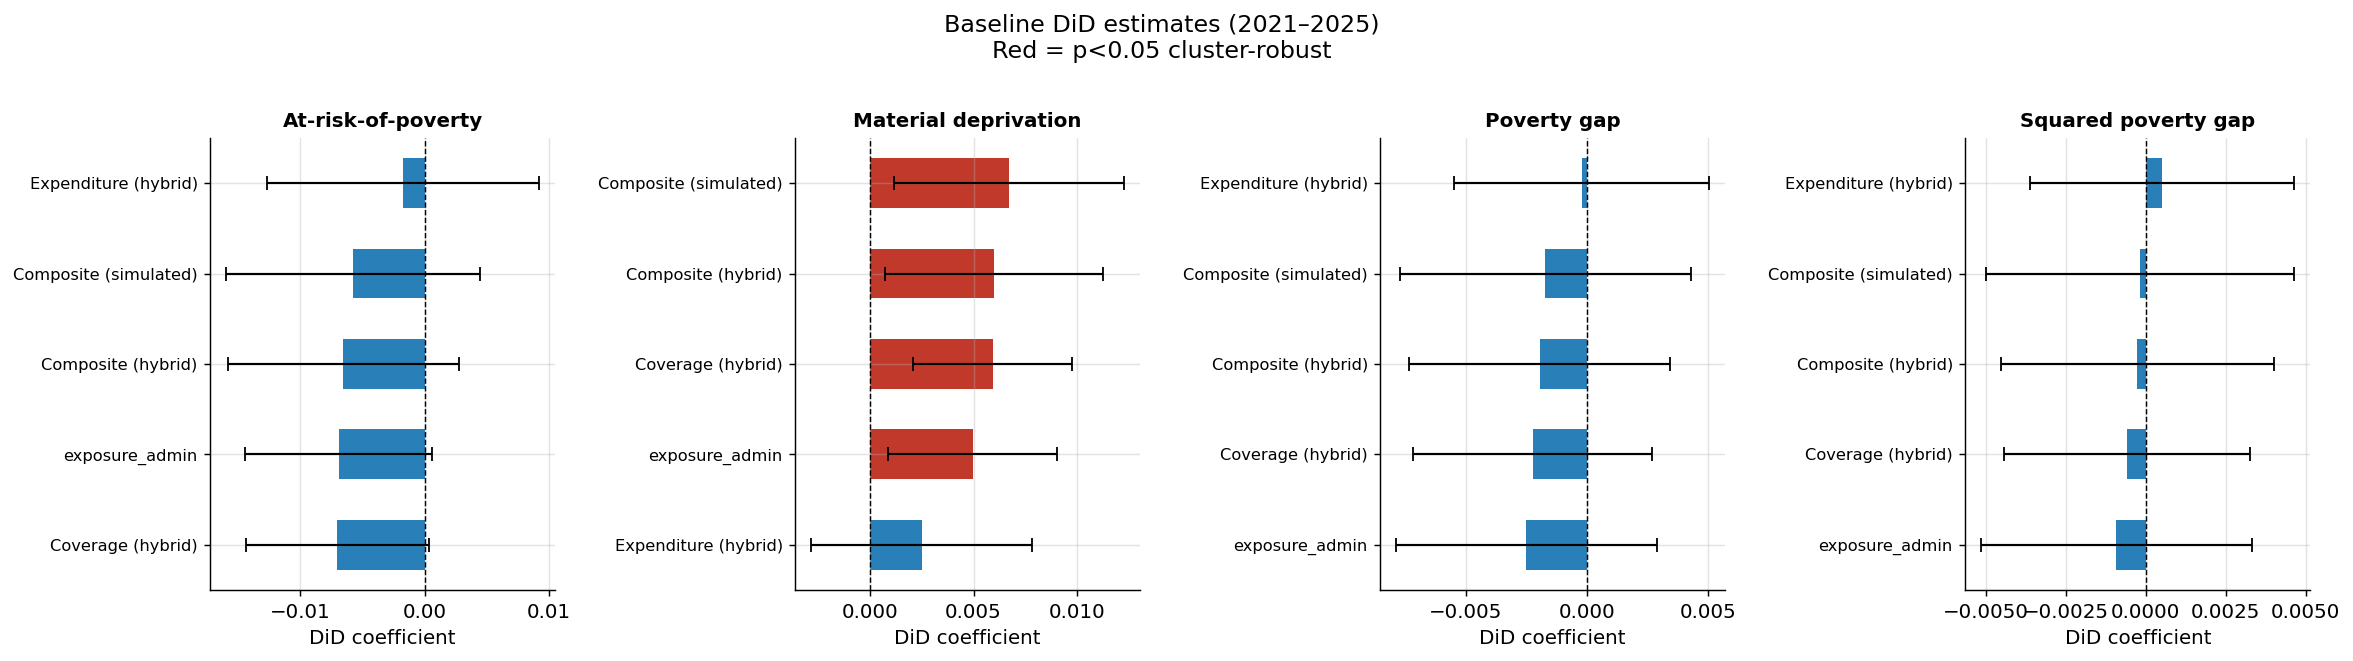

In [11]:
# ── Baseline DiD: coefficient plot by outcome × exposure spec ───────────────
did = pd.read_csv(OUT / "baseline_did" / "did_all_specs.csv")
did = did[did["label"] == "baseline_2021_2025"].copy()
did["outcome_label"] = did["outcome"].map(OUTCOME_LABELS).fillna(did["outcome"])
did["spec_label"]    = did["exposure_spec"].map(SPEC_LABELS).fillna(did["exposure_spec"])

outcomes = did["outcome"].unique()
n = len(outcomes)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes):
    sub = did[did["outcome"] == outcome].copy()
    sub = sub.sort_values("coef")
    colors = ["#c0392b" if p < 0.05 else "#2980b9" for p in sub["pval_cluster"]]
    ax.barh(sub["spec_label"], sub["coef"], xerr=[sub["coef"] - sub["ci_low"],
                                                    sub["ci_high"] - sub["coef"]],
            color=colors, capsize=4, height=0.55, error_kw=dict(lw=1.2))
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontsize=11, fontweight="bold")
    ax.set_xlabel("DiD coefficient")
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("Baseline DiD estimates (2021–2025)\nRed = p<0.05 cluster-robust", y=1.01)
plt.tight_layout()
plt.savefig(OUT / "baseline_did" / "did_coef_plot.png", bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'output\\event_study\\event_study_matdep.csv'

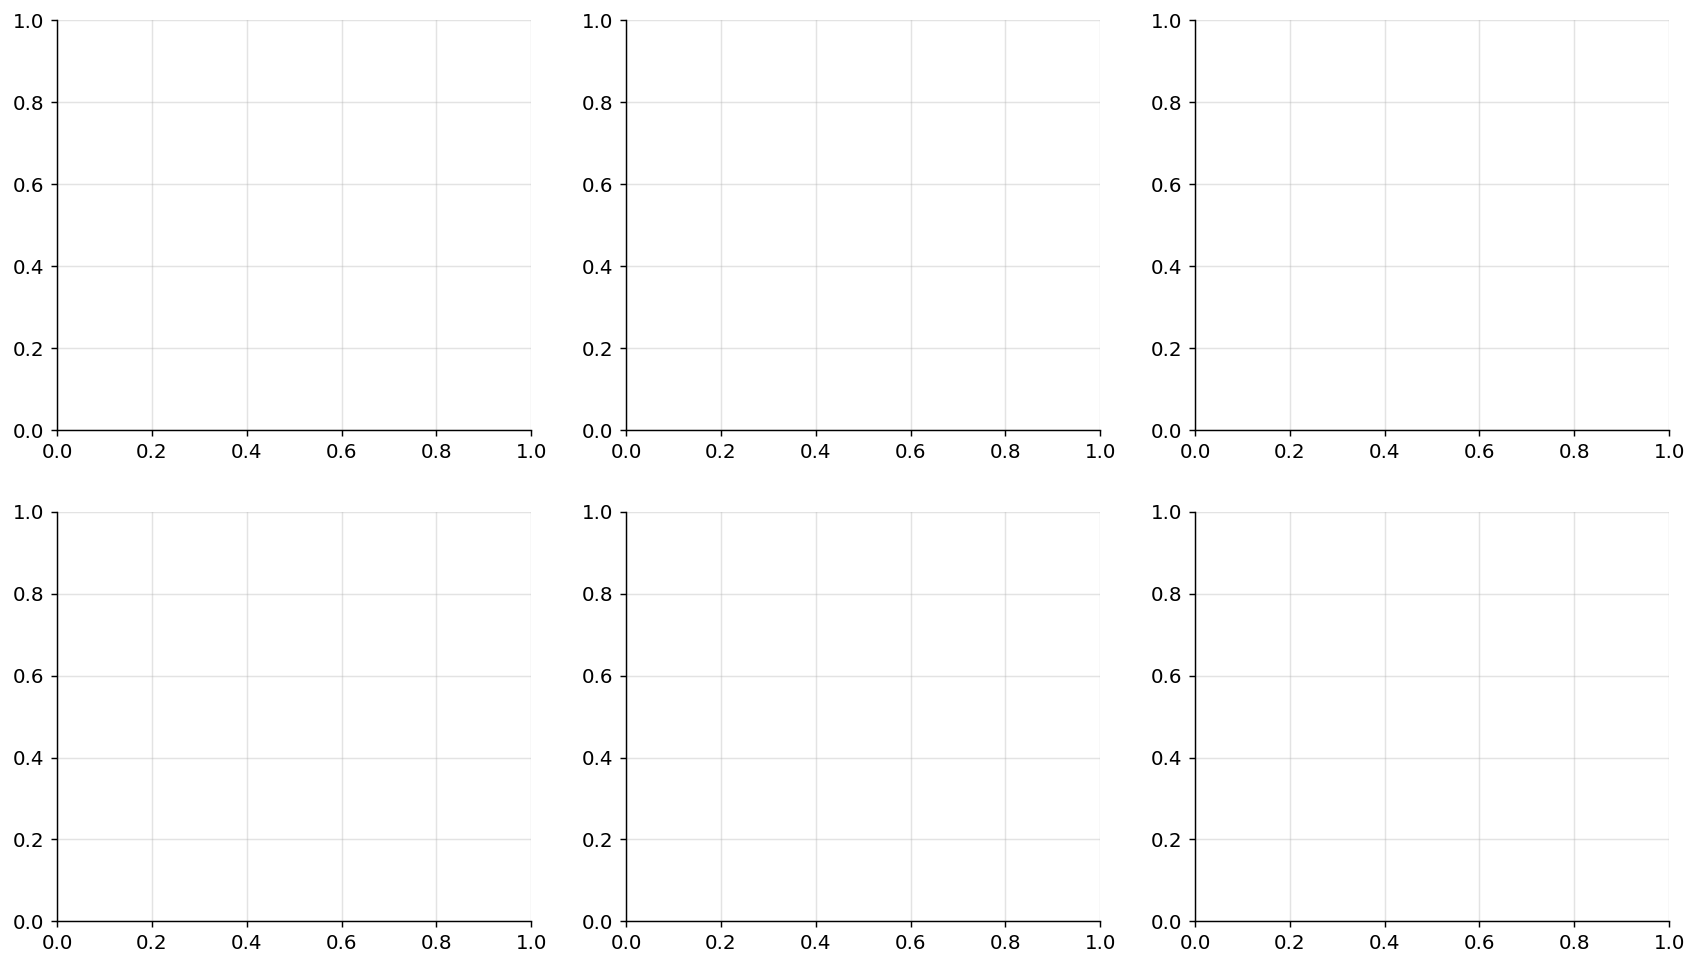

In [12]:
# ── Event study helper ────────────────────────────────────────────────────────
def plot_event_study(df, title, ax, ref_year=2019, zero_ref=True):
    df = df.copy()
    df["year"] = df["year"].astype(int)
    if zero_ref:
        df = df[df["year"] != ref_year]          # drop the normalisation year
    pre  = df[df["year"] < ref_year]
    post = df[df["year"] > ref_year]
    ref  = pd.DataFrame({"year": [ref_year], "coef": [0], "ci_low": [0], "ci_high": [0]})

    for seg, color, label in [(pre, "#e67e22", "Pre-treatment"), (post, "#27ae60", "Post-treatment")]:
        ax.errorbar(seg["year"], seg["coef"],
                    yerr=[seg["coef"] - seg["ci_low"], seg["ci_high"] - seg["coef"]],
                    fmt="o", color=color, capsize=4, lw=1.5, ms=5, label=label)
        ax.plot(seg["year"], seg["coef"], color=color, lw=1, ls="-")

    ax.scatter(ref["year"], ref["coef"], color="gray", zorder=5, s=40, label="Reference (2019)")
    ax.axvline(ref_year + 0.5, color="black", lw=1, ls="--", alpha=0.5)
    ax.axhline(0, color="black", lw=0.6, ls=":")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    return ax

# ── Event study plots ─────────────────────────────────────────────────────────
es_files = {
    "matdep":           OUT / "event_study" / "event_study_matdep.csv",
    "poverty":          OUT / "event_study" / "event_study_poverty.csv",
    "income_net_annual":OUT / "event_study" / "event_study_income_net_annual.csv",
    "poverty_gap":      OUT / "poverty_gap"  / "event_study_poverty_gap.csv",
    "poverty_gap_sq":   OUT / "poverty_gap"  / "event_study_poverty_gap_sq.csv",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (outcome, path) in enumerate(es_files.items()):
    df = pd.read_csv(path)
    plot_event_study(df, OUTCOME_LABELS.get(outcome, outcome), axes[i])
    axes[i].set_ylabel("DiD coefficient")
    if i == 0:
        axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle("Event study — composite hybrid exposure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "event_study" / "event_study_all.png", bbox_inches="tight")
plt.show()

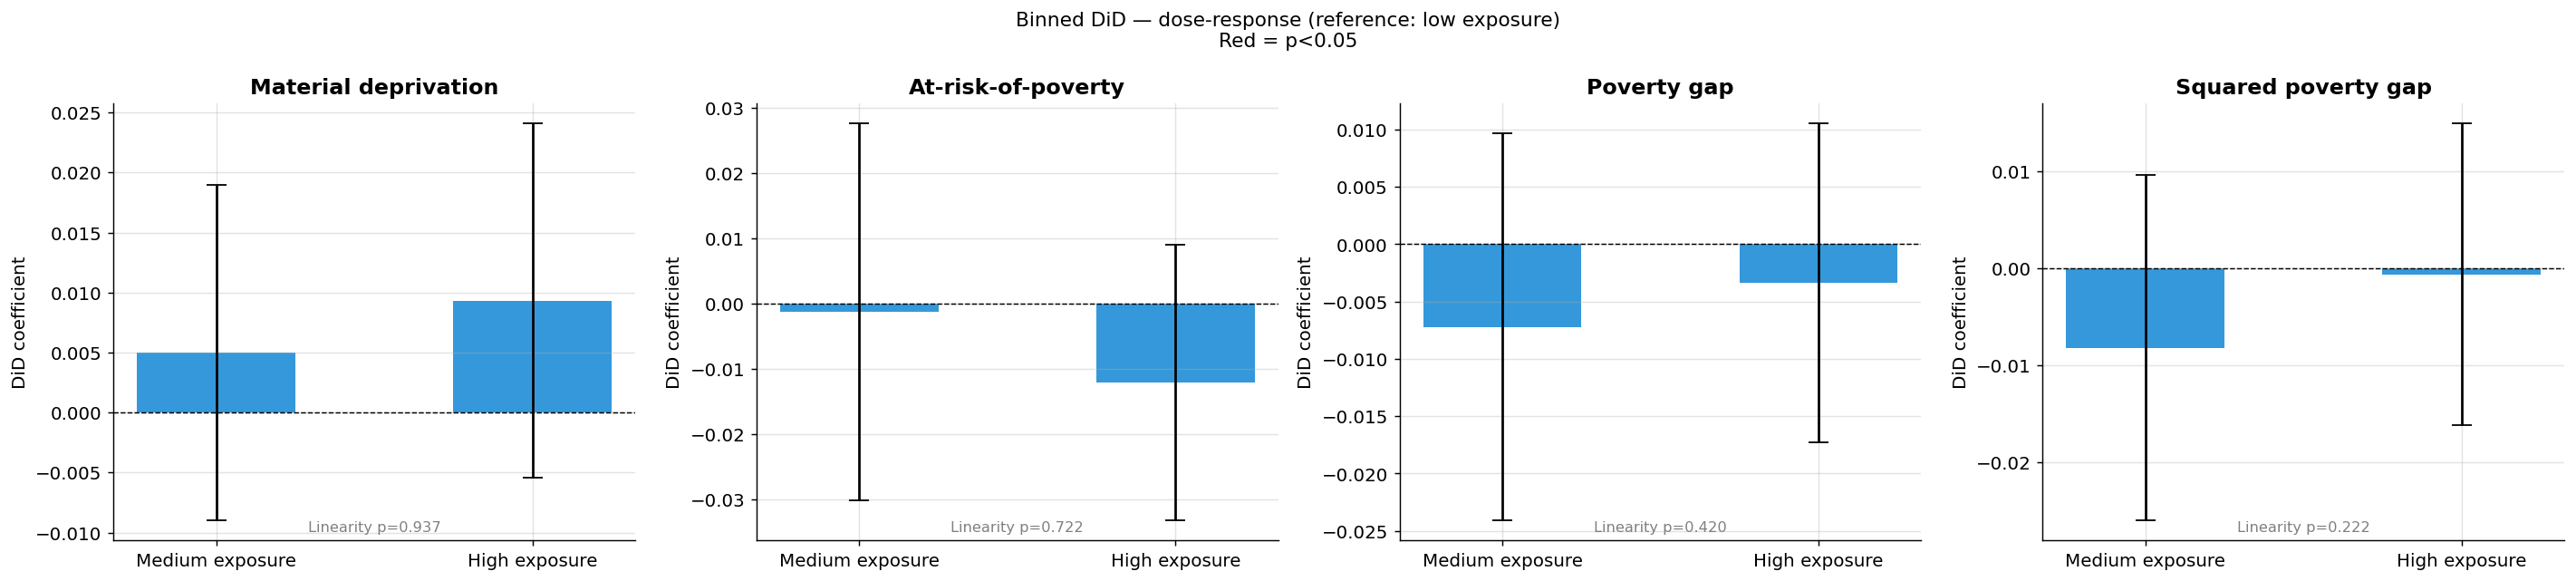

In [ ]:
# ── Binned DiD — dose-response ────────────────────────────────────────────────
bdd = pd.read_csv(OUT / "binned_did" / "binned_did_results.csv")
bdd["outcome_label"] = bdd["outcome"].map(OUTCOME_LABELS).fillna(bdd["outcome"])
outcomes_b = bdd["outcome"].unique()

fig, axes = plt.subplots(1, len(outcomes_b), figsize=(5.5 * len(outcomes_b), 5))
if len(outcomes_b) == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes_b):
    sub = bdd[bdd["outcome"] == outcome].iloc[0]
    cats   = ["Medium exposure", "High exposure"]
    coefs  = [sub["coef_medium"], sub["coef_high"]]
    ci_lo  = [sub["coef_medium"] - sub["ci_low_medium"],
              sub["coef_high"]   - sub["ci_low_high"]]
    ci_hi  = [sub["ci_high_medium"] - sub["coef_medium"],
              sub["ci_high_high"]   - sub["coef_high"]]
    colors = ["#3498db" if p > 0.05 else "#e74c3c"
              for p in [sub["pval_cluster_medium"], sub["pval_cluster_high"]]]

    ax.bar([0, 1], coefs, yerr=[ci_lo, ci_hi], color=colors, capsize=6,
           width=0.5, error_kw=dict(lw=1.5))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(cats)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("DiD coefficient")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontweight="bold")
    lin_p = sub.get("linearity_p", None)
    if lin_p is not None:
        ax.text(0.5, 0.02, f"Linearity p={lin_p:.3f}", ha="center",
                transform=ax.transAxes, fontsize=9, color="gray")

fig.suptitle("Binned DiD — dose-response (reference: low exposure)\nRed = p<0.05", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / "binned_did" / "binned_did_plot.png", bbox_inches="tight")
plt.show()

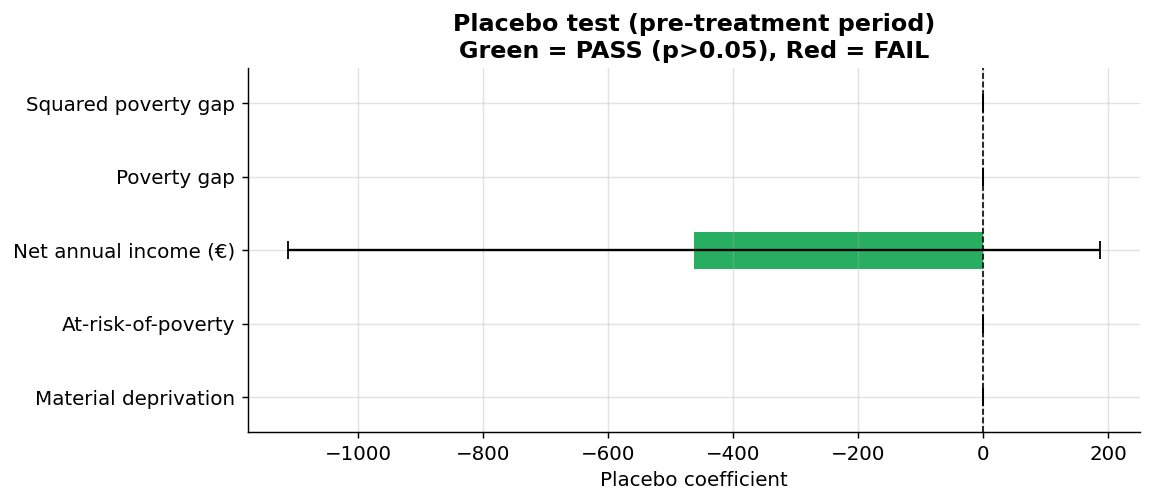

Outcome,Coef,SE,p-value,Result
Material deprivation,-0.00464,0.00320,0.1474,"PASS — placebo insignificant, parallel trends supported"
At-risk-of-poverty,-0.00668,0.00441,0.1303,"PASS — placebo insignificant, parallel trends supported"
Net annual income (€),-462.56079,302.42449,0.1261,"PASS — placebo insignificant, parallel trends supported"
Poverty gap,-0.00262,0.00286,0.3598,"PASS — placebo insignificant, parallel trends supported"
Squared poverty gap,0.00046,0.00282,0.8702,"PASS — placebo insignificant, parallel trends supported"


In [ ]:
# ── Placebo tests ─────────────────────────────────────────────────────────────
plac_main = pd.read_csv(OUT / "placebo" / "placebo_results.csv")
plac_gap  = pd.read_csv(OUT / "poverty_gap" / "placebo_poverty_gap.csv")
# gap file might not have interpretation column — add PASS/FAIL
if "interpretation" not in plac_gap.columns:
    plac_gap["interpretation"] = plac_gap["pval_cluster"].apply(
        lambda p: "PASS — placebo insignificant, parallel trends supported"
        if p > 0.05 else "FAIL — placebo significant"
    )
plac = pd.concat([plac_main, plac_gap], ignore_index=True)
plac["outcome_label"] = plac["outcome"].map(OUTCOME_LABELS).fillna(plac["outcome"])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#27ae60" if "PASS" in str(i) else "#e74c3c" for i in plac["interpretation"]]
ax.barh(plac["outcome_label"], plac["coef"],
        xerr=[plac["coef"] - plac["ci_low"], plac["ci_high"] - plac["coef"]],
        color=colors, capsize=5, height=0.5, error_kw=dict(lw=1.3))
ax.axvline(0, color="black", lw=0.9, ls="--")
ax.set_xlabel("Placebo coefficient")
ax.set_title("Placebo test (pre-treatment period)\nGreen = PASS (p>0.05), Red = FAIL", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "placebo" / "placebo_plot.png", bbox_inches="tight")
plt.show()

# summary table
display(plac[["outcome_label","coef","se","pval_cluster","interpretation"]]
    .rename(columns={"outcome_label":"Outcome","coef":"Coef","se":"SE",
                     "pval_cluster":"p-value","interpretation":"Result"})
    .style.format({"Coef":"{:.5f}","SE":"{:.5f}","p-value":"{:.4f}"})
    .hide(axis="index"))

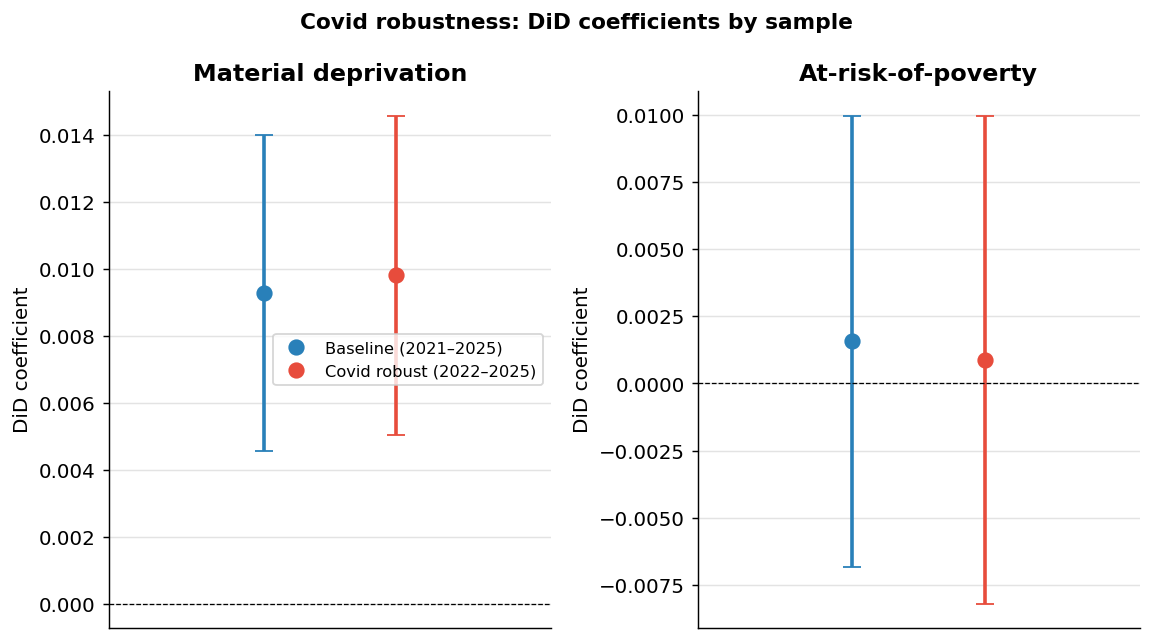

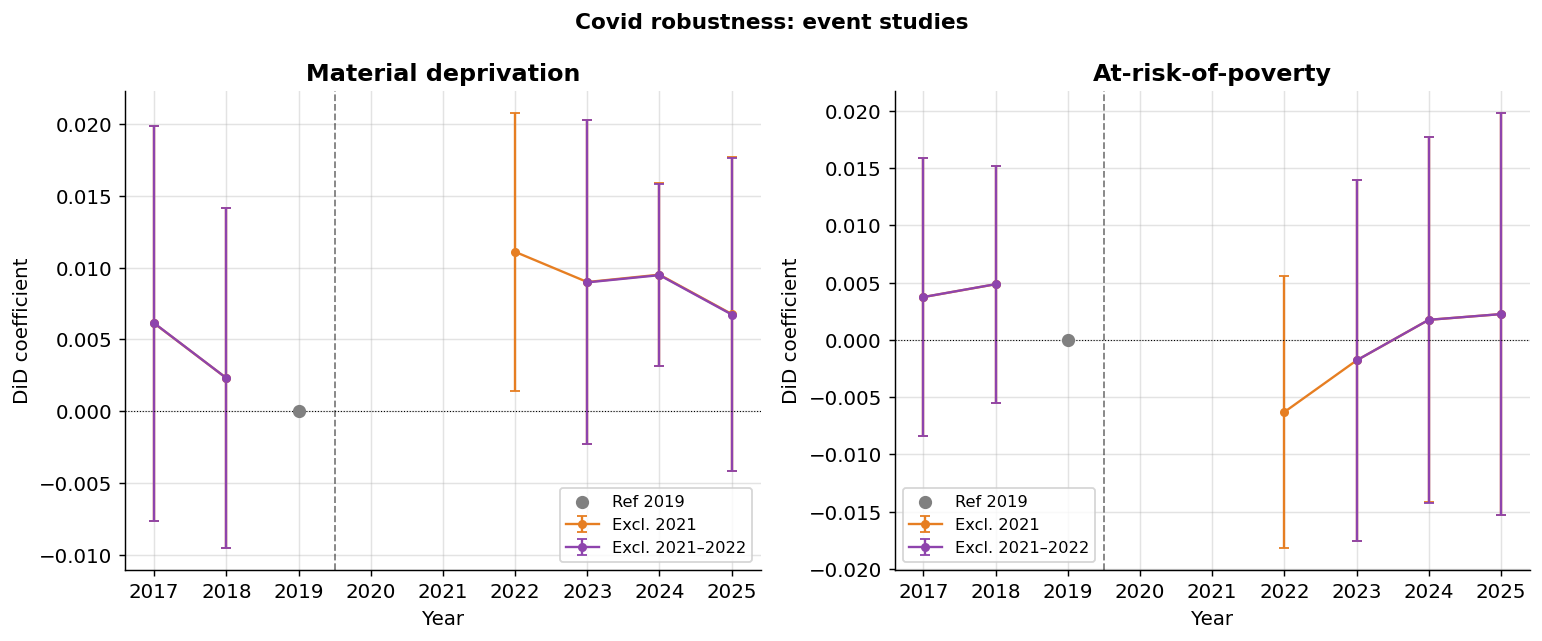

In [ ]:
# ── Covid robustness — baseline vs excl-2021 ──────────────────────────────────
base = pd.read_csv(OUT / "baseline_did" / "did_all_specs.csv")
base = base[(base["label"] == "baseline_2021_2025") &
            (base["exposure_spec"] == "exposure_composite_hybrid")].copy()
base["sample"] = "Baseline (2021–2025)"

rob = pd.read_csv(OUT / "baseline_did" / "did_covid_robust_2022_2025.csv")
rob = rob[rob["exposure_spec"] == "exposure_composite_hybrid"].copy()
rob["sample"] = "Covid robust (2022–2025)"

combined = pd.concat([base, rob], ignore_index=True)
combined["outcome_label"] = combined["outcome"].map(OUTCOME_LABELS).fillna(combined["outcome"])

outcomes_r = [o for o in OUTCOME_LABELS if o in combined["outcome"].unique()]
palette = {"Baseline (2021–2025)": "#2980b9", "Covid robust (2022–2025)": "#e74c3c"}
x_pos = {"Baseline (2021–2025)": -0.15, "Covid robust (2022–2025)": 0.15}

fig, axes = plt.subplots(1, len(outcomes_r), figsize=(4.5 * len(outcomes_r), 5))
if len(outcomes_r) == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes_r):
    sub = combined[combined["outcome"] == outcome]
    for _, row in sub.iterrows():
        x = x_pos[row["sample"]]
        ax.errorbar(x, row["coef"],
                    yerr=[[row["coef"] - row["ci_low"]], [row["ci_high"] - row["coef"]]],
                    fmt="o", color=palette[row["sample"]], capsize=5, ms=8, lw=2,
                    label=row["sample"])
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_ylabel("DiD coefficient")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontweight="bold")

handles = [plt.Line2D([0],[0], marker="o", color=c, lw=0, ms=8, label=l)
           for l, c in palette.items()]
axes[0].legend(handles=handles, fontsize=9)
fig.suptitle("Covid robustness: DiD coefficients by sample", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "covid_robust" / "covid_robust_did_comparison.png", bbox_inches="tight")
plt.show()

# Covid robustness event studies
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
for ax, outcome in zip(axes2, ["matdep", "poverty"]):
    for subdir, color, lbl in [
        ("excl_2021",      "#e67e22", "Excl. 2021"),
        ("excl_2021_2022", "#8e44ad", "Excl. 2021–2022"),
    ]:
        fpath = OUT / "covid_robust" / subdir / f"covid_robust_{outcome}.csv"
        if fpath.exists():
            df = pd.read_csv(fpath)
            df = df[df["year"] != 2019]
            pre  = df[df["year"] < 2019]
            post = df[df["year"] > 2019]
            for seg in [pre, post]:
                ax.errorbar(seg["year"], seg["coef"],
                            yerr=[seg["coef"]-seg["ci_low"], seg["ci_high"]-seg["coef"]],
                            fmt="o-", color=color, capsize=3, lw=1.3, ms=4, label=lbl)
    ax.scatter([2019], [0], color="gray", zorder=5, s=40, label="Ref 2019")
    ax.axvline(2019.5, color="black", lw=1, ls="--", alpha=0.5)
    ax.axhline(0, color="black", lw=0.6, ls=":")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("DiD coefficient")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    handles2, labels2 = ax.get_legend_handles_labels()
    seen = {}
    [seen.setdefault(l, h) for h, l in zip(handles2, labels2)]
    ax.legend(seen.values(), seen.keys(), fontsize=9)

fig2.suptitle("Covid robustness: event studies", fontsize=12, fontweight="bold")
fig2.tight_layout()
fig2.savefig(OUT / "covid_robust" / "covid_robust_event_study.png", bbox_inches="tight")
plt.show()

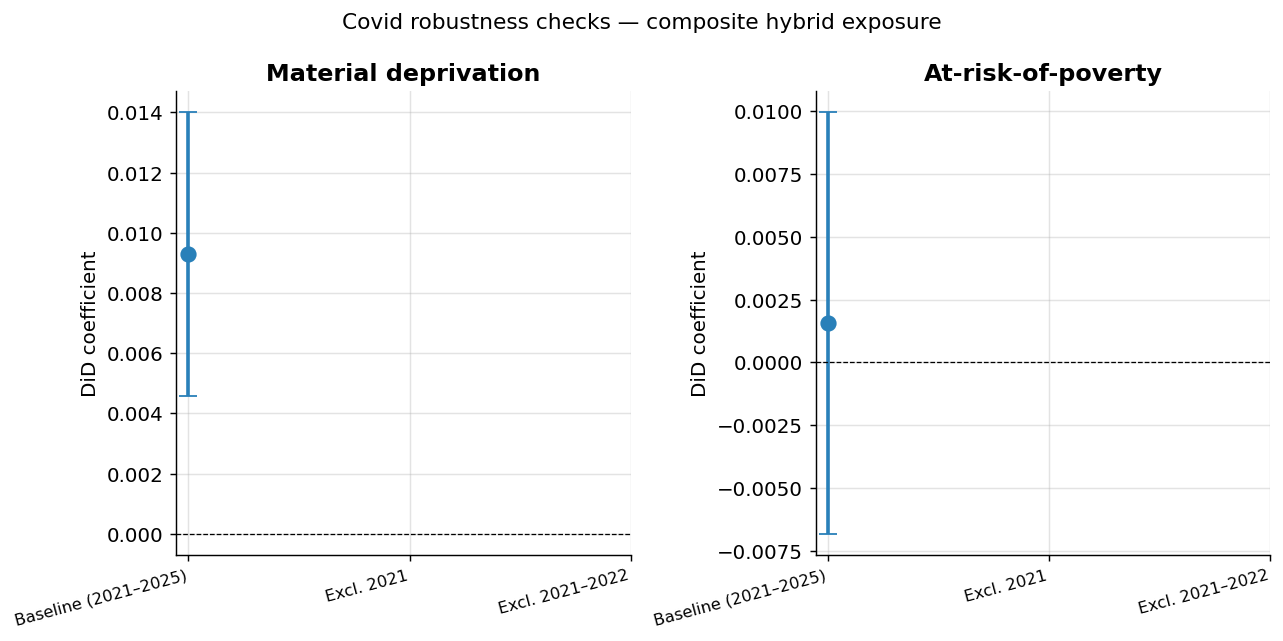

In [ ]:
# ── Covid robustness — baseline vs excl-2021 ──────────────────────────────────
base = pd.read_csv(OUT / "baseline_did" / "did_all_specs.csv")
base = base[(base["label"] == "baseline_2021_2025") &
            (base["exposure_spec"] == "exposure_composite_hybrid")].copy()
base["sample"] = "Baseline (2021–2025)"

rob = pd.read_csv(OUT / "baseline_did" / "did_covid_robust_2022_2025.csv")
rob = rob[rob["exposure_spec"] == "exposure_composite_hybrid"].copy()
rob["sample"] = "Covid robust (2022–2025)"

combined = pd.concat([base, rob], ignore_index=True)
combined["outcome_label"] = combined["outcome"].map(OUTCOME_LABELS).fillna(combined["outcome"])

outcomes_r = [o for o in OUTCOME_LABELS if o in combined["outcome"].unique()]
palette = {"Baseline (2021–2025)": "#2980b9", "Covid robust (2022–2025)": "#e74c3c"}
x_pos = {"Baseline (2021–2025)": -0.15, "Covid robust (2022–2025)": 0.15}

fig, axes = plt.subplots(1, len(outcomes_r), figsize=(4.5 * len(outcomes_r), 5))
if len(outcomes_r) == 1:
    axes = [axes]

for ax, outcome in zip(axes, outcomes_r):
    sub = combined[combined["outcome"] == outcome]
    for _, row in sub.iterrows():
        x = x_pos[row["sample"]]
        ax.errorbar(x, row["coef"],
                    yerr=[[row["coef"] - row["ci_low"]], [row["ci_high"] - row["coef"]]],
                    fmt="o", color=palette[row["sample"]], capsize=5, ms=8, lw=2,
                    label=row["sample"])
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_ylabel("DiD coefficient")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontweight="bold")

handles = [plt.Line2D([0],[0], marker="o", color=c, lw=0, ms=8, label=l)
           for l, c in palette.items()]
axes[0].legend(handles=handles, fontsize=9)

# Covid robustness event studies
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
for ax, outcome in zip(axes2, ["matdep", "poverty"]):
    for subdir, color, lbl in [
        ("excl_2021",      "#e67e22", "Excl. 2021"),
        ("excl_2021_2022", "#8e44ad", "Excl. 2021–2022"),
    ]:
        fpath = OUT / "covid_robust" / subdir / f"covid_robust_{outcome}.csv"
        if fpath.exists():
            df = pd.read_csv(fpath)
            df = df[df["year"] != 2019]
            pre  = df[df["year"] < 2019]
            post = df[df["year"] > 2019]
            for seg in [pre, post]:
                ax.errorbar(seg["year"], seg["coef"],
                            yerr=[seg["coef"]-seg["ci_low"], seg["ci_high"]-seg["coef"]],
                            fmt="o-", color=color, capsize=3, lw=1.3, ms=4, label=lbl)
    ax.scatter([2019], [0], color="gray", zorder=5, s=40, label="Ref 2019")
    ax.axvline(2019.5, color="black", lw=1, ls="--", alpha=0.5)
    ax.axhline(0, color="black", lw=0.6, ls=":")
    ax.set_title(OUTCOME_LABELS.get(outcome, outcome), fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("DiD coefficient")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    handles2, labels2 = ax.get_legend_handles_labels()
    seen = {}
    [seen.setdefault(l, h) for h, l in zip(handles2, labels2)]
    ax.legend(seen.values(), seen.keys(), fontsize=9)

fig.suptitle("Covid robustness: DiD coefficients by sample", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "covid_robust" / "covid_robust_did_comparison.png", bbox_inches="tight")
fig2.suptitle("Covid robustness: event studies", fontsize=12, fontweight="bold")
fig2.tight_layout()
fig2.savefig(OUT / "covid_robust" / "covid_robust_event_study.png", bbox_inches="tight")
plt.show()